In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Make results folder if missing
os.makedirs("results", exist_ok=True)


In [6]:
# Emotion dataset
df_emotion = pd.read_csv("data/cleaned/emotion_clean_final.csv")
print("Emotion dataset shape:", df_emotion.shape)
print(df_emotion.head())

# Big Five dataset
df_big5 = pd.read_csv("data/cleaned/big5_personality_profile.csv")
print("Big Five dataset shape:", df_big5.shape)
print(df_big5.head())


Emotion dataset shape: (63344, 2)
                                                text        label
0  I remember going to see the fireworks with my ...  sentimental
1              This was a best friend . I miss her .  sentimental
2                                We no longer talk .  sentimental
3  Was this a friend you were in love with , or j...  sentimental
4                               Where has she gone ?  sentimental
Big Five dataset shape: (5000, 5)
   Extraversion  Neuroticism  Agreeableness  Conscientiousness  Openness
0           2.9          2.8            3.2                3.1       3.4
1           3.2          2.8            3.3                3.1       3.1
2           3.0          3.2            2.9                3.2       3.2
3           3.0          2.7            3.5                2.8       3.2
4           3.0          3.5            3.2                3.0       3.5


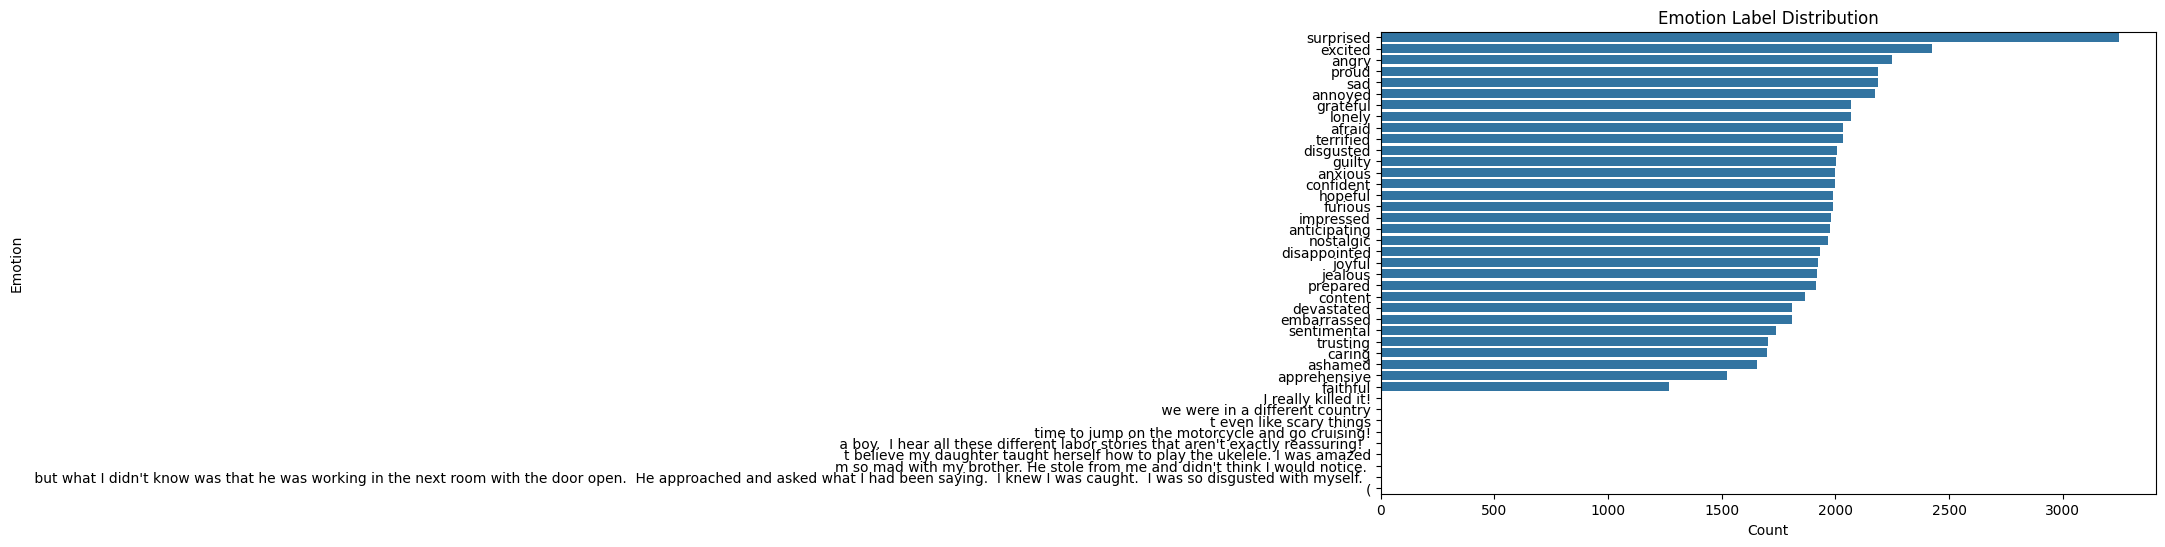

                                                    text         label
22895  I have no idea . Maybe he was irked about the ...     disgusted
42004  Oh wow , so it actually works ? I might have t...  apprehensive
36676  My husband randomly got me a laptop . I wasnt ...     surprised
42330  So disgusting to see such irresponsible parent...       anxious
44550                  Thanks . I'm gonna miss the guy .  disappointed


In [7]:
# Label distribution
plt.figure(figsize=(10,6))
sns.countplot(y="label", data=df_emotion, order=df_emotion["label"].value_counts().index)
plt.title("Emotion Label Distribution")
plt.xlabel("Count")
plt.ylabel("Emotion")
plt.savefig("results/emotion_label_distribution.png")
plt.show()

# Sample rows
print(df_emotion.sample(5))


In [8]:
#weird labels seen in the end

valid_labels = [
    "joyful", "sad", "angry", "fear", "surprised", "disgusted",
    "hopeful", "confident", "grateful", "proud", "lonely", "afraid",
    "terrified", "guilty", "anxious", "furious", "impressed",
    "nostalgic", "disappointed", "prepared", "content",
    "devastated", "embarrassed", "sentimental", "trusting",
    "caring", "ashamed", "apprehensive", "faithful"
]

# Filter out invalid labels
df_emotion = df_emotion[df_emotion["label"].isin(valid_labels)]

print("Filtered Emotion dataset shape:", df_emotion.shape)  
print(df_emotion["label"].value_counts())

df_emotion.to_csv("data/cleaned/emotion_clean_final_filtered.csv", index=False)

Filtered Emotion dataset shape: (54844, 2)
label
surprised       3247
angry           2251
proud           2189
sad             2186
grateful        2070
lonely          2067
afraid          2035
terrified       2032
disgusted       2007
guilty          2001
anxious         2000
confident       1999
hopeful         1989
furious         1988
impressed       1979
nostalgic       1968
disappointed    1931
joyful          1923
prepared        1914
content         1868
devastated      1811
embarrassed     1807
sentimental     1740
trusting        1703
caring          1697
ashamed         1653
apprehensive    1523
faithful        1266
Name: count, dtype: int64


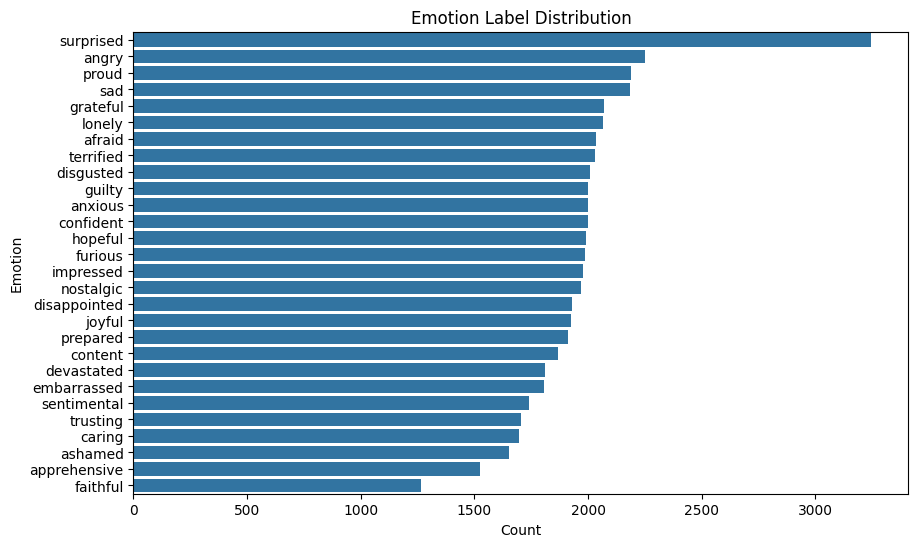

                                                    text       label
30784  I got a hand written thank you note from a co-...       proud
4401   Hello , last week I walked into a breakroom an...    faithful
26338                               nah , a clean escape       angry
19153  oh no . that can be nerve wracking . are you a...       angry
55143  That's incredibly sad , I'm so sorry for your ...  devastated


In [9]:
#lets check again lol

# Label distribution
plt.figure(figsize=(10,6))
sns.countplot(y="label", data=df_emotion, order=df_emotion["label"].value_counts().index)
plt.title("Emotion Label Distribution")
plt.xlabel("Count")
plt.ylabel("Emotion")
plt.savefig("results/emotion_label_distribution.png")
plt.show()

# Sample rows
print(df_emotion.sample(5))

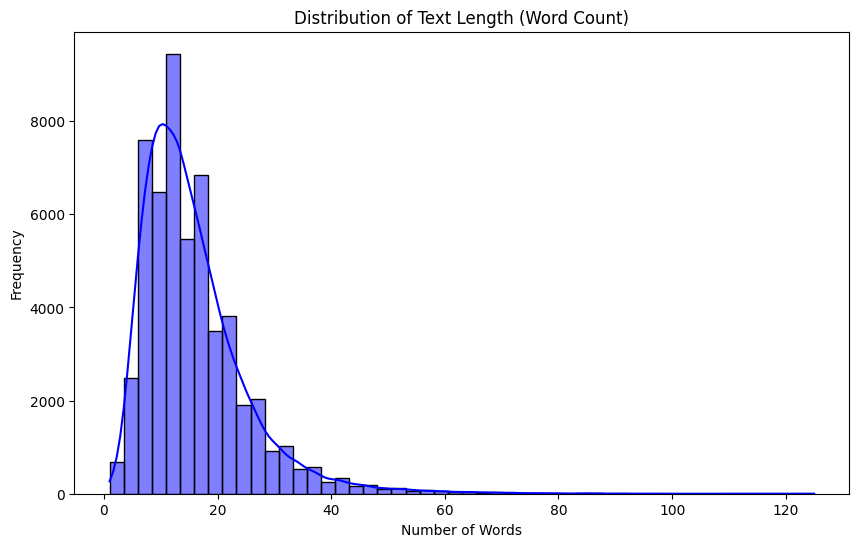

Average text length: 15.780431770111589
Median text length: 14.0
Max text length: 125


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add a column with word counts
df_emotion["text_length"] = df_emotion["text"].apply(lambda x: len(str(x).split()))

# Plot histogram
plt.figure(figsize=(10,6))
sns.histplot(df_emotion["text_length"], bins=50, kde=True, color="blue")
plt.title("Distribution of Text Length (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.savefig("results/emotion_text_length_distribution.png")
plt.show()

# Print some stats
print("Average text length:", df_emotion["text_length"].mean())
print("Median text length:", df_emotion["text_length"].median())
print("Max text length:", df_emotion["text_length"].max())
